# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation


## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [2]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.


**Respuesta:** Taxi tiene 500 estados y 6 acciones. Tiene muchos más estados que FrozenLake (16) porque el estado no es solo la posición: junta la posición del taxi (25 casillas del mapa de 5x5), dónde está el pasajero (5 opciones, las 4 paradas o dentro del taxi) y el destino (4 paradas). Eso da 25 x 5 x 4 = 500. En FrozenLake el estado era solamente la casilla.

## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [3]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 1
Nuevo estado: 286
Recompensa: -1
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?


**Respuesta:** en la ejecución quedó:

s_t = 386, que es el estado codificado donde empezó el taxi (posición del taxi, pasajero y destino).

a_t = 1, que es la acción North, moverse hacia arriba.

r_{t+1} = 1 negativo, es el castigo normal de cada paso para que el taxi no se demore.

s_{t+1} = 286, el nuevo estado. Bajó 100 porque el taxi subió una fila y en la codificación cada fila vale 100 (5 columnas x 5 pasajero x 4 destinos).

## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [4]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$


**Respuesta:** 500 x 6 = 3000 valores Q. Es una tabla mucho más grande que la de FrozenLake (16 x 4 = 64), por eso el agente necesita más episodios para llenarla bien.

## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [5]:
def choose_action(Q, state, epsilon, env):
    if random.random() < epsilon:
        return env.action_space.sample()
    # si hay empate se escoge al azar entre las mejores
    best = np.flatnonzero(Q[state] == np.max(Q[state]))
    return int(np.random.choice(best))

## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [6]:
def update_q(Q, state, action, reward, next_state, alpha, gamma, done=False):
    if done:
        target = reward
    else:
        target = reward + gamma * np.max(Q[next_state])
    td_error = target - Q[state, action]
    Q[state, action] = Q[state, action] + alpha * td_error
    return Q

## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [7]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            action = choose_action(Q, state, epsilon, env)

            next_state, reward, terminated, truncated, _ = env.step(action)

            update_q(Q, state, action, reward, next_state, alpha, gamma, done=terminated)

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards

## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [8]:
Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


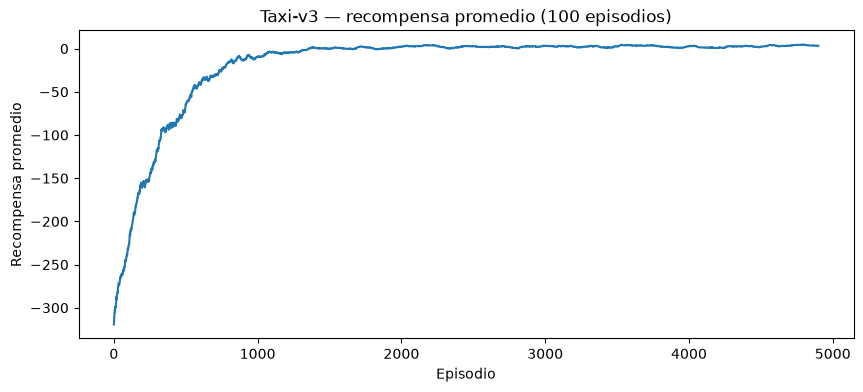

In [9]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v3 — recompensa promedio ({window} episodios)")
plt.show()


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?


**Respuesta:** sí mejora bastante. Al principio el promedio está cerca de 300 negativo porque el taxi se mueve casi al azar y hace muchos pickup y dropoff ilegales que quitan 10. Sube rápido en los primeros 500 episodios y alrededor del episodio 1200 a 1400 ya se estabiliza cerca de 0 o un poco por encima. Los últimos 500 episodios dieron un promedio de 3.47 con desviación de 6.84.

No es una convergencia perfecta. El promedio de entrenamiento queda en unos 3 a 4 porque se sigue explorando con epsilon = 0.1 (1 de cada 10 acciones es al azar) y la curva tiene algo de ruido. Cuando evalué la política greedy sin exploración dio una media de 7.69, que es una política razonablemente buena, pero con alpha pequeño y solo 5000 episodios puede que algunos estados raros no estén bien aprendidos.

## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [10]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [11]:
frames_initial, reward_initial = play_episode(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
frames_to_video(frames_initial, interval=500)


Recompensa total sin entrenamiento: -176


Ahora observe el agente entrenado.


In [12]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
frames_to_video(frames_trained, interval=500)


Recompensa total después del entrenamiento: 10


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?


**Respuesta:** la diferencia es enorme. El taxi sin entrenamiento tiene la Q table en cero, entonces todas las acciones empatan y escoge al azar. Se mueve de un lado a otro sin sentido, intenta recoger y dejar donde no hay pasajero y en los 50 pasos sacó 176 negativo. No logra completar la tarea.

El agente entrenado va directo a la parada del pasajero, lo recoge, va al destino y lo deja. Terminó con recompensa total de 10, que significa que lo hizo en 11 pasos (20 de la entrega menos 1 por cada paso). No hace acciones innecesarias ni pickups ilegales. La evidencia visual es que en el video el taxi sigue un camino corto y el episodio se termina solo, mientras que el sin entrenar nunca termina y da vueltas.

## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [13]:
state = 123

print("Estado:", state)
print("Q-values:", Q_trained[state])
print("Mejor acción:", np.argmax(Q_trained[state]))


Estado: 123
Q-values: [-3.0679743  -0.80677082 -2.80774664  3.94947757 -5.82522556 -6.98789597]
Mejor acción: 3


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?


**Respuesta:**

1. La acción con mayor valor es la 3 (West) con Q = 3.95. Decodificando el estado 123 el taxi está en la fila 1 columna 1, el pasajero está en la parada R (arriba a la izquierda) y el destino es B. Moverse al oeste lo acerca a recoger al pasajero, así que tiene sentido.
2. Que una acción tenga Q mayor significa que el agente espera conseguir más recompensa acumulada (descontada) si la hace y después sigue la política. Por ejemplo Pickup (5.83 negativo) y Dropoff (6.99 negativo) son las peores porque ahí no hay pasajero y serían ilegales.
3. Porque Q incluye lo que viene después, no solo el paso actual. Moverse al oeste da 1 negativo inmediato igual que moverse al este, pero Q West es positivo porque deja al taxi más cerca de recoger y entregar al pasajero y ganar el 20. Es la suma descontada de todas las recompensas futuras.

## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.


**Respuesta:** cambié solamente alpha de 0.1 a 0.5 (gamma y epsilon iguales).

Velocidad de aprendizaje: con alpha = 0.5 aprende mucho más rápido. El promedio móvil se volvió positivo cerca del episodio 340, mientras que con 0.1 fue cerca del 1353. En la gráfica la curva naranja llega a 0 antes del episodio 500.

Estabilidad: una vez arriba, las dos curvas se ven parecidas. Con alpha = 0.5 la desviación de los últimos 500 episodios fue un poco más alta (7.47 contra 6.84), lo que tiene sentido porque cada experiencia mueve más a Q y se nota más el ruido.

Recompensa final: en entrenamiento quedaron parecidas (3.47 con 0.1 y 2.86 con 0.5, la diferencia es por la exploración). Con la política greedy, alpha = 0.5 sacó 8.15 contra 7.69, un poco mejor, porque en el mismo número de episodios tuvo más tiempo para afinar la tabla.

Comportamiento: en el video con alpha = 0.5 el taxi también hace la ruta completa con recompensa 10, igual que el original. Como Taxi es determinístico, un alpha grande no causa problemas y acelera el aprendizaje.

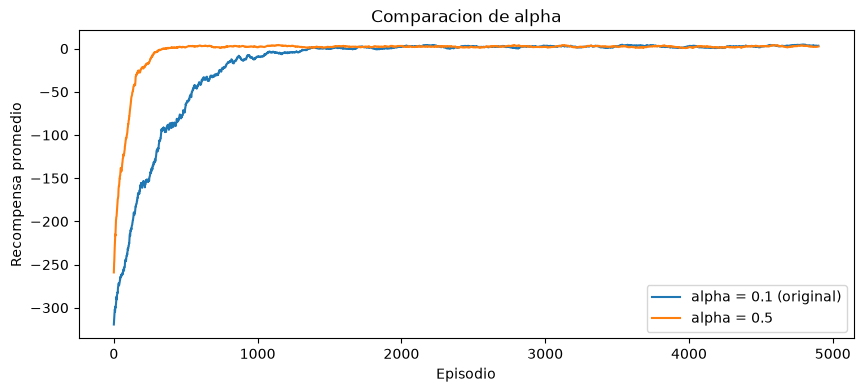

alpha 0.1: promedio ultimos 500 episodios = 3.47, std = 6.84, primer promedio movil positivo en episodio 1353
alpha 0.5: promedio ultimos 500 episodios = 2.86, std = 7.47, primer promedio movil positivo en episodio 340

Politica greedy alpha 0.1: media 7.69, std 2.33
Politica greedy alpha 0.5: media 8.15, std 2.55


In [14]:
def evaluar(env, Q, n=100, max_steps=200):
    total = []
    for _ in range(n):
        state, _ = env.reset()
        r_ep = 0
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            r_ep += reward
            if terminated or truncated:
                break
        total.append(r_ep)
    return np.mean(total), np.std(total)

# cambio solo alpha: de 0.1 a 0.5
Q_alpha, rewards_alpha = train_q_learning(
    env,
    np.zeros((n_states, n_actions)),
    episodes=5000,
    alpha=0.5,
    gamma=0.95,
    epsilon=0.1
)

ma_alpha = np.convolve(rewards_alpha, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(moving_average, label="alpha = 0.1 (original)")
plt.plot(ma_alpha, label="alpha = 0.5")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title("Comparacion de alpha")
plt.legend()
plt.show()

for nombre, r in [("alpha 0.1", rewards), ("alpha 0.5", rewards_alpha)]:
    r = np.array(r)
    primer = np.argmax(np.convolve(r, np.ones(window) / window, mode="valid") > 0)
    print(f"{nombre}: promedio ultimos 500 episodios = {r[-500:].mean():.2f}, std = {r[-500:].std():.2f}, primer promedio movil positivo en episodio {primer}")

print()
print("Politica greedy alpha 0.1: media %.2f, std %.2f" % evaluar(env, Q_trained))
print("Politica greedy alpha 0.5: media %.2f, std %.2f" % evaluar(env, Q_alpha))

In [15]:
frames_alpha, reward_alpha = play_episode(env, Q_alpha, max_steps=200, seed=7)
print("Recompensa total con alpha = 0.5:", reward_alpha)
frames_to_video(frames_alpha, interval=500)

Recompensa total con alpha = 0.5: 10


## Entrega

El notebook debe contener:

1. implementación de `choose_action`;
2. implementación de `update_q`;
3. implementación de `train_q_learning`;
4. curva de aprendizaje;
5. visualización del agente antes y después del entrenamiento;
6. respuestas a las siete preguntas.

No es necesario modificar las funciones auxiliares de visualización.
